<a href="https://colab.research.google.com/github/Oktavian19/PCVK_Ganjil_2025/blob/main/Week5_25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
from google.colab import drive

drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
from matplotlib import pyplot as plt
import numpy as np
import math
import os
import glob

## D1 - Percobaan Histogram

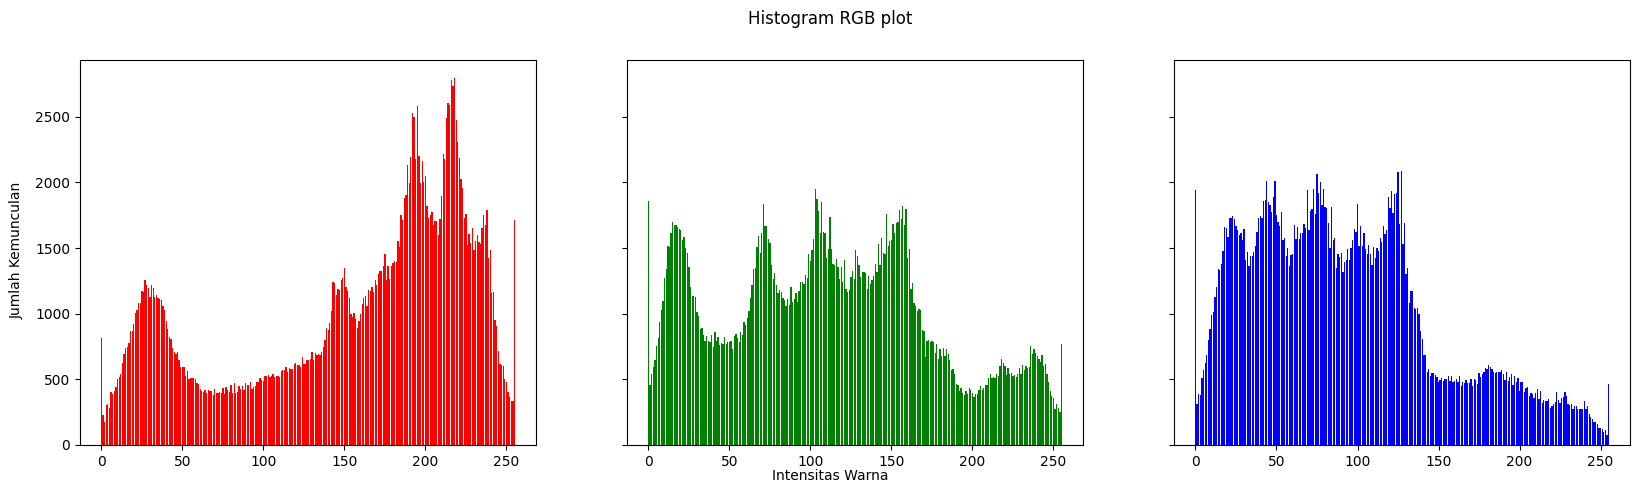

In [46]:
# Membuat histogram image (manual)
img = cv.imread('/content/drive/MyDrive/asset/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

names = np.arange(256)

def manual_image_histogram(img):
  if img.ndim == 3:
    height, width, depth = np.shape(img)

    red = [0]*256
    green = [0]*256
    blue = [0]*256

    for y in range(0, height):
      for x in range(0, width):
        red[img[y, x, 0]] += 1
        green[img[y, x, 1]] += 1
        blue[img[y, x, 2]] += 1

    return red, green, blue
  elif img.ndim == 2:
    height, width = np.shape(img)

    histogram = [0]*256

    for y in range(0, height):
      for x in range(0, width):
        intensity = img[y, x]
        histogram[intensity] += 1

    return histogram

red, green, blue = manual_image_histogram(img)

fig, axes = plt.subplots(1, 3, figsize=[20, 5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axes[0].bar(names, red, color='red')
axes[1].bar(names, green, color='green')
axes[2].bar(names, blue, color='blue')
plt.show()

### Pertanyaan Praktikum D1
1. Buatlah histogram citra yang sama akan tetapi menggunakan library yang dimiliki oleh NumPy yaitu "Histogram". Bandingkan hasilnya. Apakah output muncul sama?
2. Buatlah histogram dengan menggunakan image KTM lama.jpg. Analisis distribusi intensitas dari histogram yang dihasilkan apakah gambar cenderung gelap, terang, atau kontras rendah.

### Jawaban Praktikum D1

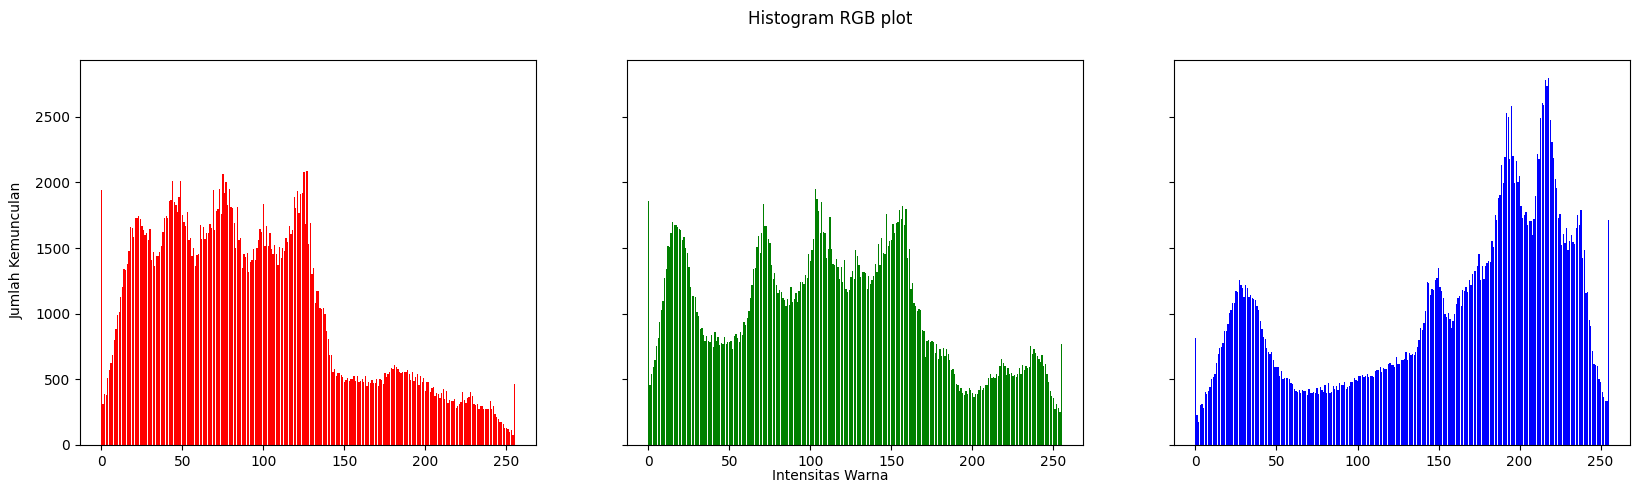

In [47]:
b,g,r = cv.split(img)

names = np.arange(256)

blue = np.histogram(b.flatten(), bins=256, range=[0, 256])[0]
green = np.histogram(g.flatten(), bins=256, range=[0, 256])[0]
red = np.histogram(r.flatten(), bins=256, range=[0, 256])[0]

fig, axes = plt.subplots(1, 3, figsize=[20, 5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axes[0].bar(names, red, color='red')
axes[1].bar(names, green, color='green')
axes[2].bar(names, blue, color='blue')
plt.show()

1. Output yang ditampilkan mirip terutama pada channel green. Namun terlihat seperti mirror untuk channel red dan blue

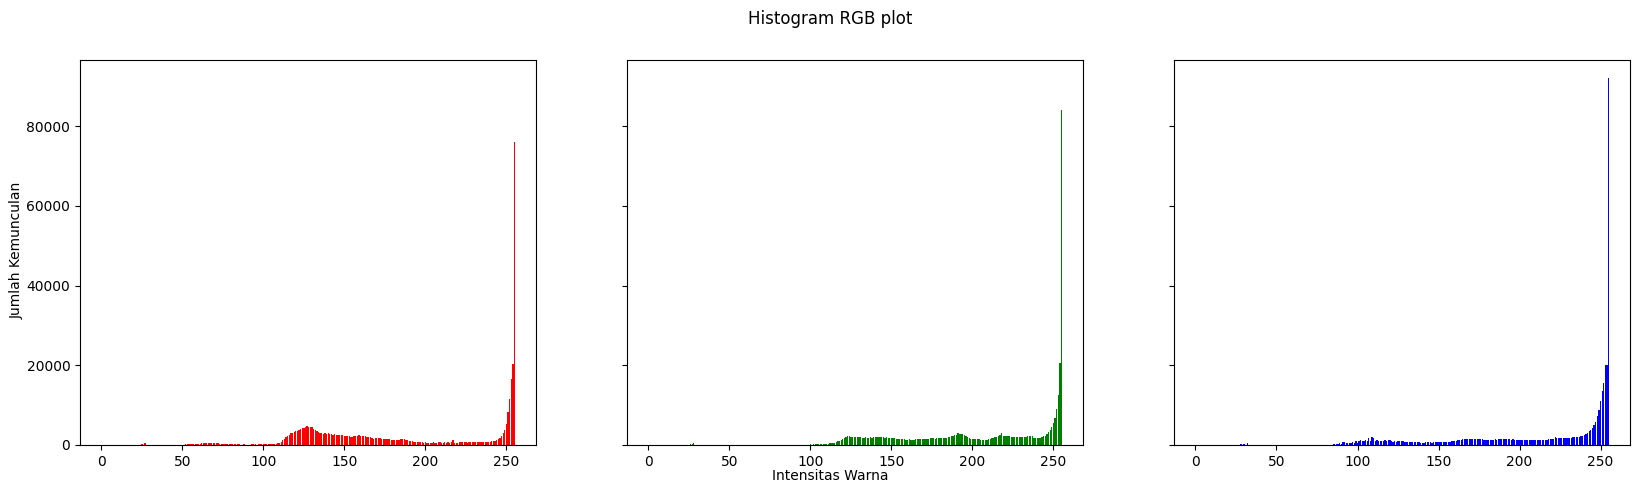

In [56]:
# Membuat histogram image (manual)
img = cv.imread('/content/drive/MyDrive/asset/KTM lama.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

names = np.arange(256)

red, green, blue = manual_image_histogram(img)

fig, axes = plt.subplots(1, 3, figsize=[20, 5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axes[0].bar(names, red, color='red')
axes[1].bar(names, green, color='green')
axes[2].bar(names, blue, color='blue')
plt.show()

2. Gambar akan terlihat cenderung gelap, karena histogram menunjukkan data condong ke kanan untuk semua channel

### D-2 Percobaan Histogram Equalization

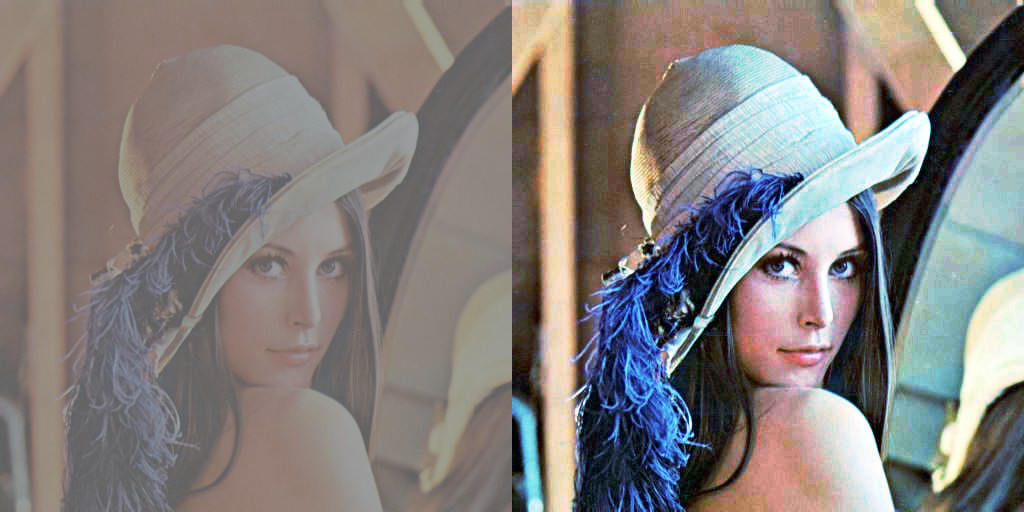

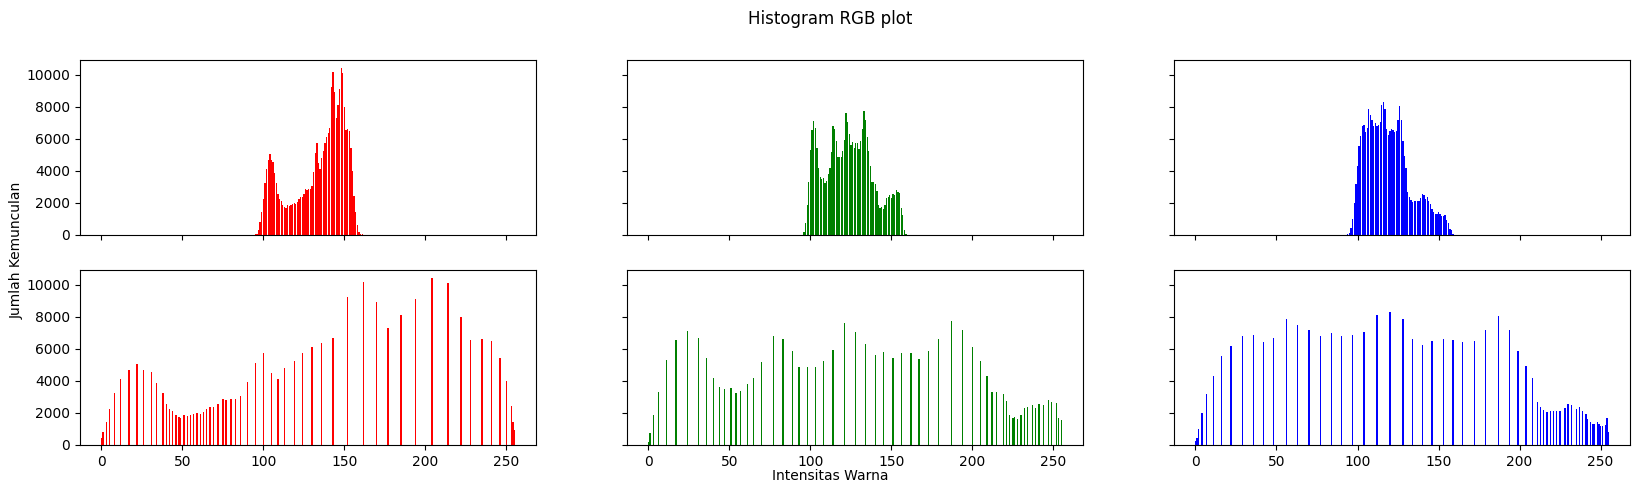

In [48]:
# Membuat histogram image (manual)
img = cv.imread('/content/drive/MyDrive/asset/lena_lc.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

names = np.arange(256)

def manual_equalization(img):
  if img.ndim == 3:
    height, width, depth = np.shape(img)
    total_pixels= height * width

    red, green, blue = manual_image_histogram(img)

    cdf_red, cdf_green, cdf_blue = [], [], []
    sum_r, sum_g, sum_b = 0, 0, 0

    for i in range(256):
      sum_r += red[i] / total_pixels
      sum_g += green[i] / total_pixels
      sum_b += blue[i] / total_pixels

      cdf_red.append(sum_r)
      cdf_green.append(sum_g)
      cdf_blue.append(sum_b)

    # s_k = (L-1) * CDF
    L = 256
    sk_red = np.round(np.array(cdf_red) * (L - 1)).astype('uint8')
    sk_green = np.round(np.array(cdf_green) * (L - 1)).astype('uint8')
    sk_blue = np.round(np.array(cdf_blue) * (L - 1)).astype('uint8')

    img_eq = np.zeros_like(img)
    for y in range(0, height):
      for x in range(0, width):
        img_eq[y, x, 0] = sk_red[img[y, x, 0]]
        img_eq[y, x, 1] = sk_green[img[y, x, 1]]
        img_eq[y, x, 2] = sk_blue[img[y, x, 2]]

    return img_eq

  elif img.ndim == 2:
    height, width = np.shape(img)
    total_pixels= height * width

    histogram = manual_image_histogram(img)

    cdf = []
    sum = 0

    for i in range(256):
      sum += histogram[i] / total_pixels
      cdf.append(sum)

    L = 256

    sk = np.round(np.array(cdf) * (L - 1)).astype('uint8')

    img_eq = np.zeros_like(img)
    for y in range(height):
        for x in range(width):
            img_eq[y, x] = sk[img[y, x]]

    return img_eq

red, green, blue = manual_image_histogram(img)

img_eq = manual_equalization(img)
red_eq, green_eq, blue_eq = manual_image_histogram(img_eq)

img = cv.cvtColor(img, cv.COLOR_RGB2BGR)
img_eq = cv.cvtColor(img_eq, cv.COLOR_RGB2BGR)
final_frame = cv.hconcat((img, img_eq))
cv2_imshow(final_frame)

fig, axes = plt.subplots(2, 3, figsize=[20, 5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axes[0, 0].bar(names, red, color='red')
axes[0, 1].bar(names, green, color='green')
axes[0, 2].bar(names, blue, color='blue')
axes[1, 0].bar(names, red_eq, color='red')
axes[1, 1].bar(names, green_eq, color='green')
axes[1, 2].bar(names, blue_eq, color='blue')
plt.show()

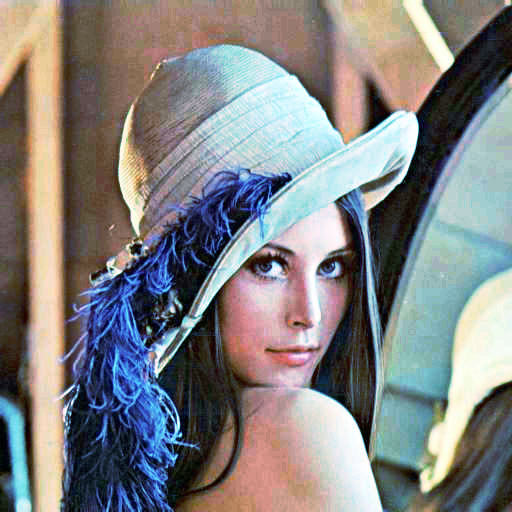

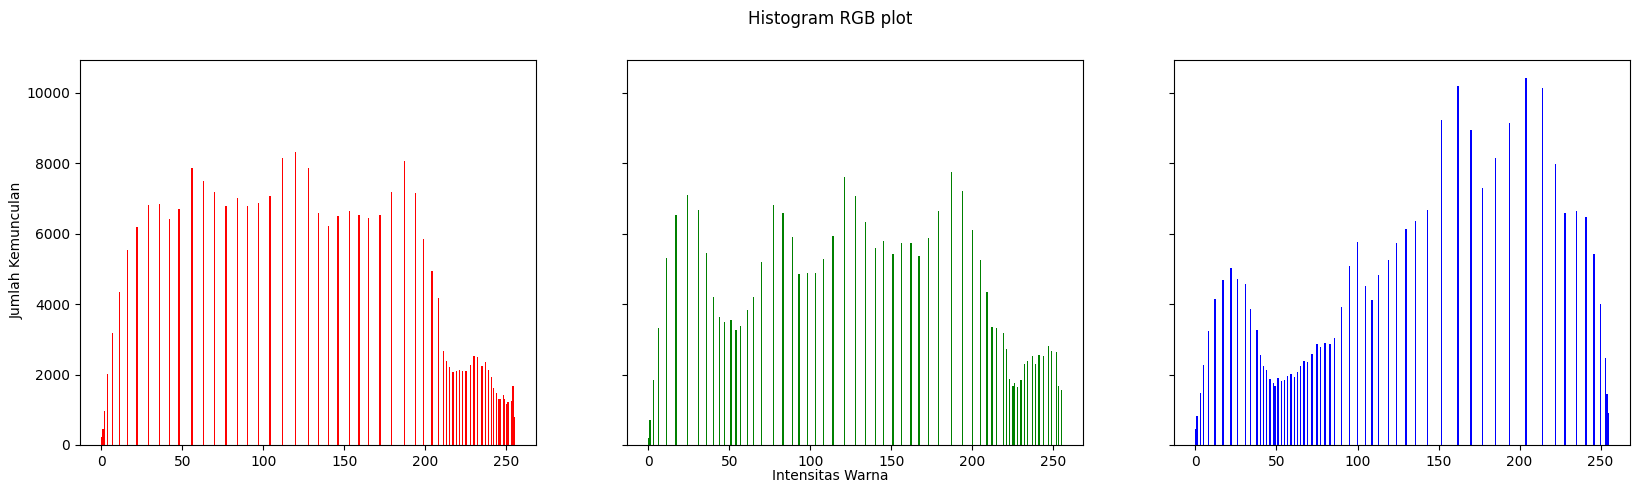

In [49]:
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
b,g,r = cv.split(img)

names = np.arange(256)

b_equalized = cv.equalizeHist(b)
g_equalized = cv.equalizeHist(g)
r_equalized = cv.equalizeHist(r)

img_equalized_rgb = cv.merge([r_equalized, g_equalized, b_equalized])

red_equalized = cv.calcHist([r_equalized], [0], None, [256], [0, 256])
green_equalized = cv.calcHist([g_equalized], [0], None, [256], [0, 256])
blue_equalized = cv.calcHist([b_equalized], [0], None, [256], [0, 256])

cv2_imshow(img_equalized_rgb)

fig, axes = plt.subplots(1, 3, figsize=[20, 5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axes[0].bar(names, red_equalized.ravel(), color='red')
axes[1].bar(names, green_equalized.ravel(), color='green')
axes[2].bar(names, blue_equalized.ravel(), color='blue')
plt.show()

### Pertanyaan Praktikum D2
1. Perbandingan Citra Lena
  
    a. Gunakan hasil histogram equalization pada citra lena.jpg.
    
    b. Hitung nilai PSNR antara citra asli dan citra hasil equalization.

    c. Apakah nilai PSNR tinggi atau rendah? Apa arti nilai tersebut terhadap kualitas visual citra? Apakah ada detail baru yang muncul setelah equalization?

2. Gunakan Citra KTM Lama.jpg

    a. Terapkan histogram equalization pada citra KTM lama.jpg.

    b. Tampilkan citra asli, citra hasil equalization, serta histogram keduanya dalam satu layout.

    c. Bandingkan citra KTM lama.jpg sebelum dan sesudah histogram equalization.
    Jelaskan perbedaan yang terlihat secara visual (misalnya pada detail wajah, teks, atau latar belakang). Apakah perubahan tersebut meningkatkan kualitas informasi dari citra atau justru membuat citra terlihat terlalu “keras”.

### Jawaban Pertanyaan Praktikum D2

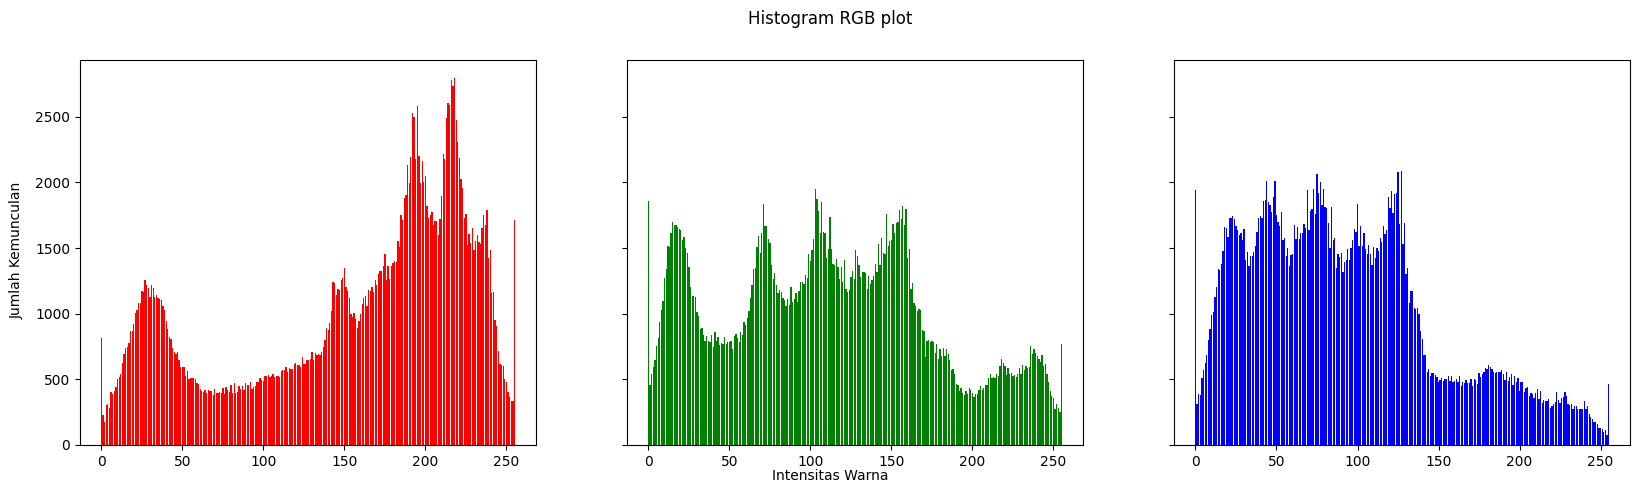

In [50]:
img = cv.imread('/content/drive/MyDrive/asset/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

names = np.arange(256)

red, green, blue = manual_image_histogram(img)

fig, axes = plt.subplots(1, 3, figsize=[20, 5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axes[0].bar(names, red, color='red')
axes[1].bar(names, green, color='green')
axes[2].bar(names, blue, color='blue')
plt.show()


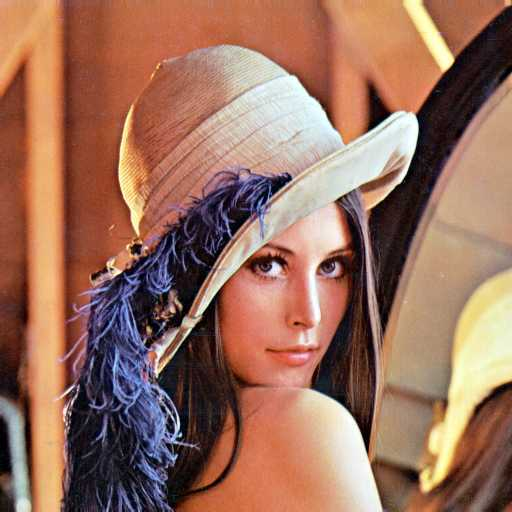

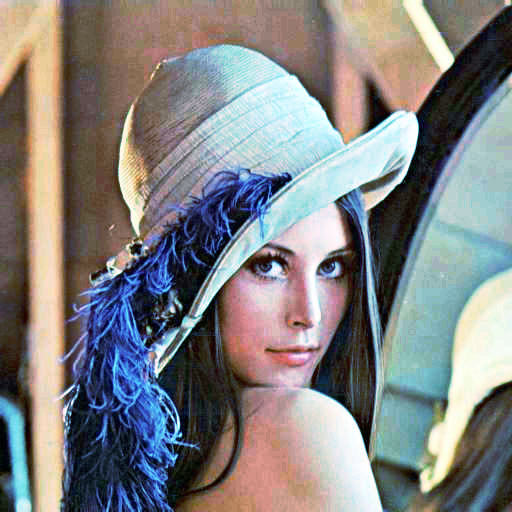

PSNR: 65.81 dB


In [51]:
def PSNR (img1, img2):
  mse = np.mean((img1/255. - img2/255.) ** 2)
  if mse == 0:
    return 100
  max_pixel = 255.0
  psnr = 20 * np.log10(max_pixel/np.sqrt(mse))
  return psnr

img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
cv2_imshow(img)
cv2_imshow(img_eq)

print(f'PSNR: {PSNR(img, img_eq):.2f} dB')

c. Kualitas equalization termasuk bagus karena memiliki PSNR di atas 40dB

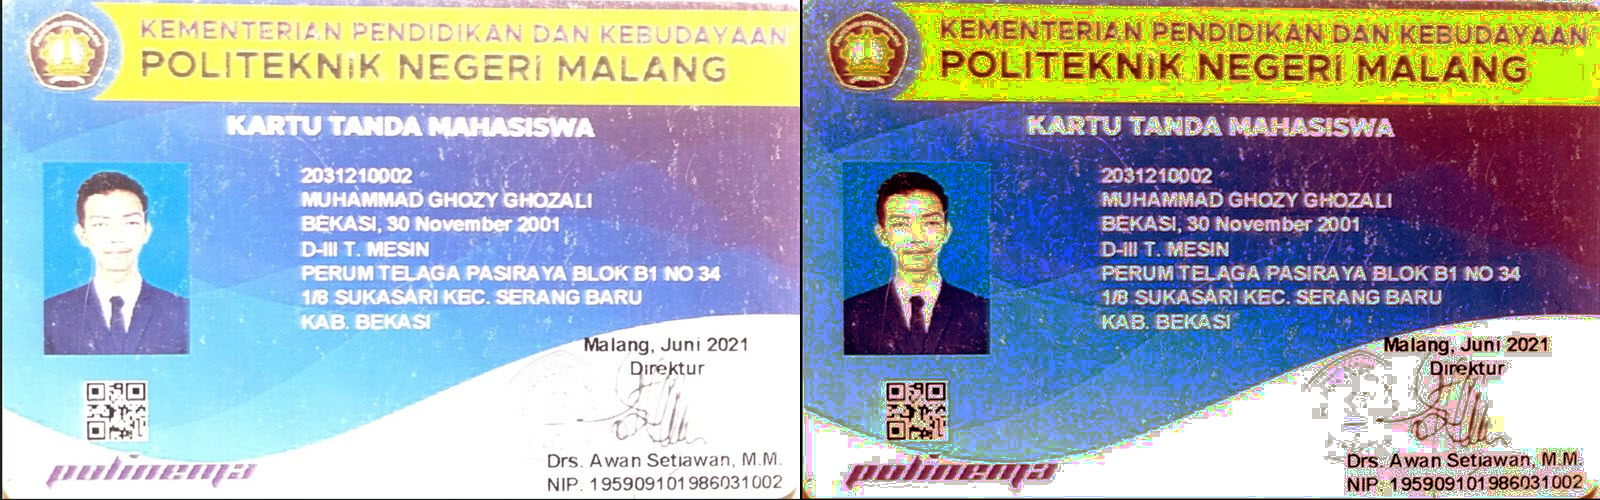

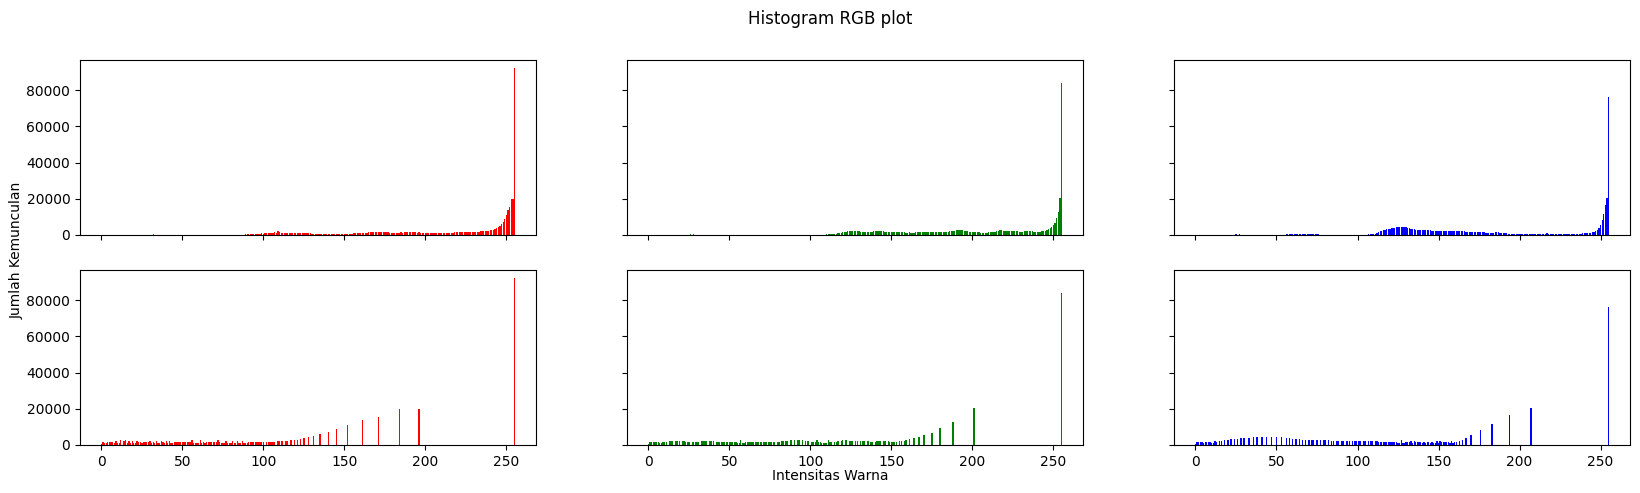

In [52]:
img = cv.imread('/content/drive/MyDrive/asset/KTM lama.jpg')

names = np.arange(256)

red, green, blue = manual_image_histogram(img)

img_eq = manual_equalization(img)
red_eq, green_eq, blue_eq = manual_image_histogram(img_eq)

final_frame = cv.hconcat((img, img_eq))
cv2_imshow(final_frame)

fig, axes = plt.subplots(2, 3, figsize=[20, 5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axes[0, 0].bar(names, red, color='red')
axes[0, 1].bar(names, green, color='green')
axes[0, 2].bar(names, blue, color='blue')
axes[1, 0].bar(names, red_eq, color='red')
axes[1, 1].bar(names, green_eq, color='green')
axes[1, 2].bar(names, blue_eq, color='blue')
plt.show()


c. Citra KTM lama yang telah dilakukan equalization akan terlihat lebih jelas detail baik dari tekstur ktm, logo ktm bahkan wajah yang sebelumnya terlihat terlalu terang pada foto asli. Sehingga dapat disimpulkan bahwa equalization dapat meningkatkan kulitas informasi citra

### D-3 Tugas Praktikum Dithering

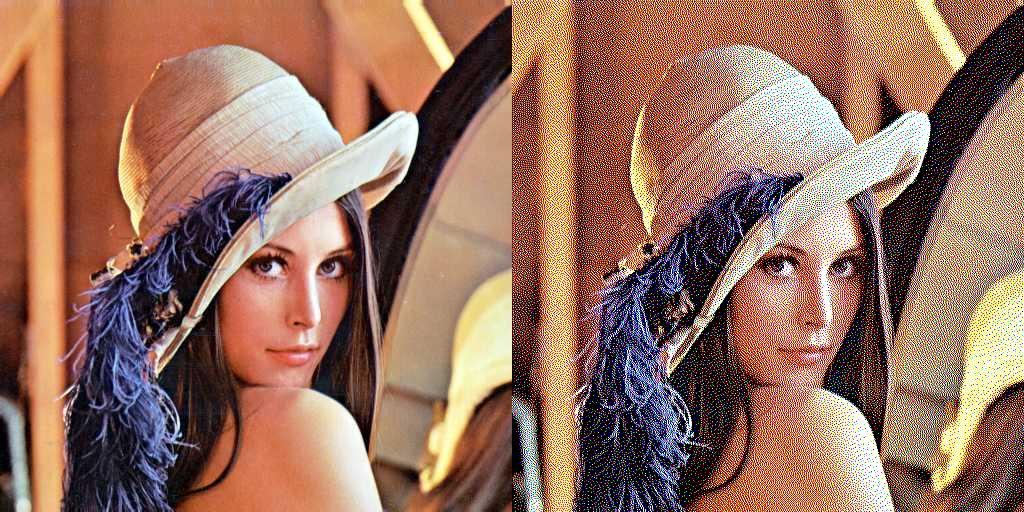

In [53]:
img = cv.imread('/content/drive/MyDrive/asset/lena.jpg')

def floyd_steinberg_dithering(image):
    dithered_image = np.copy(image).astype(float)
    height, width, channels = dithered_image.shape

    for c in range(channels):
      for y in range(height):
          for x in range(width):
              old_pixel = dithered_image[y, x, c]
              new_pixel = 255 if old_pixel > 127 else 0
              dithered_image[y, x, c] = new_pixel
              quant_error = old_pixel - new_pixel

              if x + 1 < width:
                  dithered_image[y, x + 1, c] += quant_error * 7 / 16

              if x - 1 >= 0 and y + 1 < height:
                  dithered_image[y + 1, x - 1, c] += quant_error * 3 / 16

              if y + 1 < height:
                  dithered_image[y + 1, x, c] += quant_error * 5 / 16

              if x + 1 < width and y + 1 < height:
                  dithered_image[y + 1, x + 1, c] += quant_error * 1 / 16

    return np.clip(dithered_image, 0, 255).astype(np.uint8)

dithered_image = floyd_steinberg_dithering(img)
cv2_imshow(cv.hconcat((img, dithered_image)))

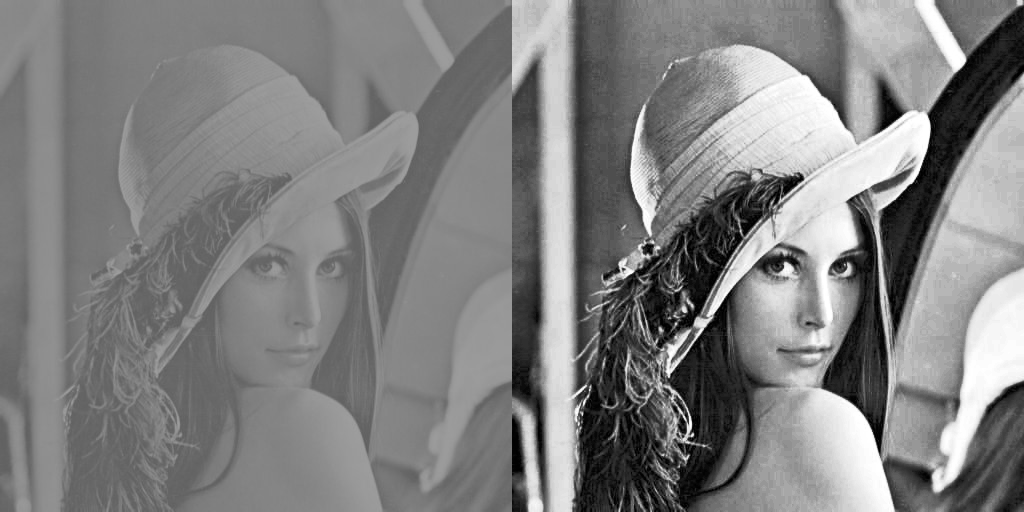

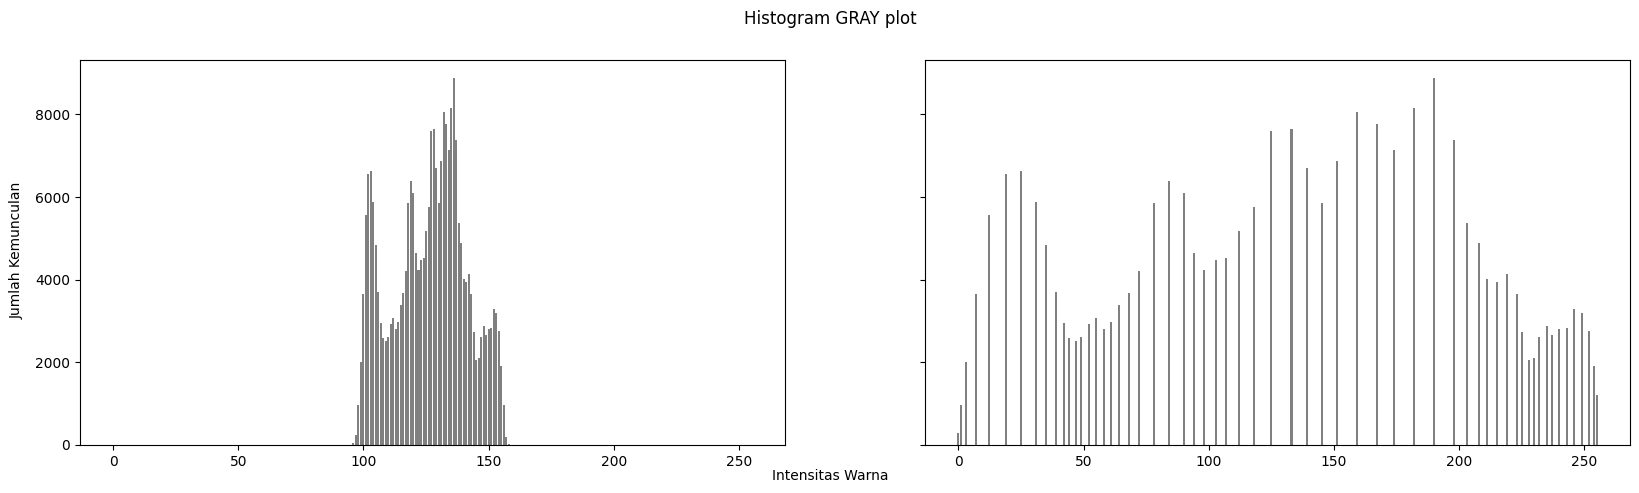

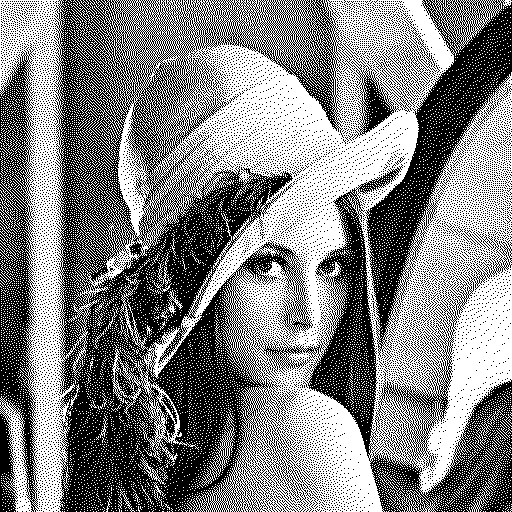

In [54]:
img = cv.imread('/content/drive/MyDrive/asset/lena_lc.jpg', cv.IMREAD_GRAYSCALE)

names = np.arange(256)

hist_asli = manual_image_histogram(img)

img_eq = manual_equalization(img)
hist_eq = manual_image_histogram(img_eq)

img = cv.cvtColor(img, cv.COLOR_RGB2BGR)
img_eq = cv.cvtColor(img_eq, cv.COLOR_RGB2BGR)
final_frame = cv.hconcat((img, img_eq))
cv2_imshow(final_frame)

fig, axes = plt.subplots(1, 2, figsize=[20, 5], sharex=True, sharey=True)
fig.suptitle('Histogram GRAY plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axes[0].bar(names, hist_asli, color='gray')
axes[1].bar(names, hist_eq, color='gray')
plt.show()

dithered_gray_image = floyd_steinberg_dithering(img_eq)
cv2_imshow(dithered_gray_image)